# MovieLens 100k Analysis
The MovieLens 100K dataset is a commonly used benchmark dataset for recommendation system research (Harper & Konstan, 2015). It contains user demographic information, movie metadata, and user ratings, making it suitable for demonstrating distributed data processing and analytical workflows.

**Objective:**
The objective of this analysis is to conduct an end-to-end data processing using Apache Spark and Apache Cassandra to analyse the MovieLens 100K dataset.

Data Source: https://grouplens.org/datasets/movielens/100k/

**Reference:**

Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets. ACM Transactions on Interactive Intelligent Systems, 5(4), 1–19. https://doi.org/10.1145/2827872

## 1.0 Import Required Libraries
All required Python libraries for Apache Spark and Cassandra integration were imported. These libraries provide functionality for distributed computing, DataFrame manipulation, SQL queries and communication with Cassandra. The imported libraries include:
1. SparkSession for Spark application.
2. SparkSQL for aggregation and filtering.
3. Cassandra connector for reading and writing data.

The MovieLens dataset consists of three files include u.data that comprised of user ratings, u.user consisting user demographic information and u.item for movie information. These files were loaded from HDFS into Apache Spark to enable distributed processing.

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window
import sys

print("Initializing Spark Session...")
spark = SparkSession.builder \
    .appName("MovieLensFullAnalysis") \
    .config("spark.cassandra.connection.host", "127.0.0.1") \
    .getOrCreate()

DATA_PATH = "file:///home/p166242/ml-100k/u.data"
ITEM_PATH = "file:///home/p166242/ml-100k/u.item"
USER_PATH = "file:///home/p166242/ml-100k/u.user"

## 2.0 Resilient Distributed Dataset (RDD) Parsing and Data Preprocessing
Each MovieLens files were first parsed as RDDs because Spark initially reads distributed data as collections of records. RDDs provide fault tolerance and parallel processing capabilities, allowing the data to be distributed across multiple worker nodes. The RDDs were subsequently transformed into Spark DataFrames by assigning appropriate column names and data types. DataFrames provide a structured tabular representation of the data, enabling efficient SQL-based querying and Catalyst query optimization (Ambrust et al., 2015).

The datasets were cleaned and preprocessed before performing analytical queries. Preprocessing steps include assigning meaningful column names, converting columns into appropriate data types, extracting movie genres, and preparing datasets for joins.

**Reference:**

Armbrust, M., Xin, R., Lian, C., Huai, Y., Liu, D., Bradley, J., Meng, X., Kaftan, T., Franklin, M., Ghodsi, A., Zaharia, M., Databricks, & Csail, M. (2015). Spark SQL: Relational Data Processing in Spark. https://doi.org/10.1145/2723372.2742797

In [ ]:
print("Loading and parsing datasets...")

# 1. Parse u.data
raw_data = spark.read.text(DATA_PATH)
data_rdd = raw_data.rdd.map(lambda r: r.value.split("\t")).map(
    lambda c: (c[0], c[1], int(c[2]), int(c[3]))
)
df_data = spark.createDataFrame(data_rdd, ["user_id", "movie_id", "rating", "timestamp"])

# 2. Parse u.item
genre_labels = [
    "unknown", "Action", "Adventure", "Animation", "Childrens", "Comedy", "Crime", 
    "Documentary", "Drama", "Fantasy", "Film_Noir", "Horror", "Musical", "Mystery", 
    "Romance", "Sci_Fi", "Thriller", "War", "Western"
]
raw_item = spark.read.text(ITEM_PATH)

def parse_item(line):
    parts = line.split("|")
    movie_id = parts[0]
    movie_title = parts[1]
    genres = [genre_labels[i] for i, val in enumerate(parts[5:]) if val == "1"]
    primary_genre = genres[0] if genres else "Unknown"
    return (movie_id, movie_title, primary_genre)

item_rdd = raw_item.rdd.map(lambda r: r.value).map(parse_item)
df_items = spark.createDataFrame(item_rdd, ["movie_id", "movie_title", "genre"])

# 3. Parse u.user
raw_user = spark.read.text(USER_PATH)
user_rdd = raw_user.rdd.map(lambda r: r.value.split("|")).map(
    lambda c: (c[0], int(c[1]), c[2], c[3], c[4])
)
df_users = spark.createDataFrame(user_rdd, ["user_id", "age", "gender", "occupation", "zip_code"])

print("DataFrames created successfully.")

## 3.0 Cassandra Sink Configurations
Apache Cassandra is configured by creating the required keyspace and tables for storing the anlytical results. A reusable function is implemented to write Spark DataFrames directly into Cassandra. Separating computation from storage allows processed results to be reused without repeatedly executing expensive Spark computations. Cassandra is particularly suitable because it supports scalable distributed storage and high-speed data retrieval (Lakshman & Malik, 2010).

**Reference:**

Lakshman, A., & Malik, P. (2010). Cassandra. ACM SIGOPS Operating Systems Review, 44(2), 35. https://doi.org/10.1145/1773912.1773922

In [ ]:
def save_to_cassandra(df, table_name):
    df.write \
        .format("org.apache.spark.sql.cassandra") \
        .options(table=table_name, keyspace="movielens") \
        .mode("append") \
        .save()

## 4.0 Analytical Tasks
### 4.1 Task i: Calculate the Average Rating for Each Movie
The movie ratings dataset was grouped by 'movie_id' using SparkSQL, and the average rating was calculated for each movie. The resulting DataFrame was then written into a Cassandra table and later read back into Spark to validate that the data had been stored successfully.

In [ ]:
# Task i
movie_avgs = df_data.groupBy("movie_id").agg(F.avg("rating").alias("avg_rating"))
save_to_cassandra(movie_avgs, "movie_ratings_avg")

### 4.2 Task ii: Identify the Top Ten Movies with the Highest Average Ratings
The average movie ratings calculated in Task i were sorted in descending order using Spark SQL. The movie information dataset was joined with the aggregated ratings so that movie titles could be displayed together with their corresponding average ratings. Only the top ten highest-rated movies were retained before storing the results in Cassandra and reading them back into Spark for validation.

In [ ]:
# Task ii
top_10_named = movie_avgs.join(df_items.select("movie_id", "movie_title"), "movie_id")
top_10_movies = top_10_named.orderBy(F.desc("avg_rating")).select("movie_id", "movie_title", "avg_rating").limit(10)
save_to_cassandra(top_10_movies, "top_movies")

### 4.3 Task iii: Identify Heavy Raters and Their Favourite Movie Genre
Users who had rated at least 50 movies were first identified from the ratings dataset. The ratings data were then joined with the movie dataset to associate each rated movie with its corresponding genre information. For each qualifying user, the number of ratings submitted for each genre was counted. The genre with the highest frequency was then selected as the user's favourite genre. The processed results were subsequently stored in Cassandra and retrieved for validation.

In [ ]:
# Task iii
df_user_genres = df_data.join(df_items, "movie_id")
user_genre_counts = df_user_genres.groupBy("user_id", "genre").agg(F.count("rating").alias("genre_count"))
user_total_counts = df_data.groupBy("user_id").agg(F.count("rating").alias("rating_count")).filter("rating_count >= 50")
window_spec = Window.partitionBy("user_id").orderBy(F.desc("genre_count"))
user_top_genre = user_genre_counts.withColumn("rank", F.row_number().over(window_spec)).filter("rank = 1").drop("rank")
heavy_raters_genres = user_total_counts.join(user_top_genre, "user_id").select("user_id", F.col("genre").alias("favorite_genre"), "rating_count")
save_to_cassandra(heavy_raters_genres, "user_favorite_genres")

### 4.4 Task iv: Find Users Who Are Less Than 20 Years Old
The user dataset was filtered using Spark SQL to retrieve records where the user's age was less than 20 years. Relevant demographic attributes, including user ID, age, gender, occupation, and ZIP code, were retained before writing the filtered data into Cassandra and validating the stored records.

In [ ]:
# Task iv
young_users = df_users.filter("age < 20")
save_to_cassandra(young_users, "young_users")

### 4.5 Task v: Find Scientists Aged Between 30 and 40 Years
The user dataset was filtered to retrieve individuals whose occupation was **scientist** and whose age was between **30 and 40 years**, inclusive. The selected demographic attributes were stored in Cassandra and subsequently read back into Spark to verify successful data persistence.

In [ ]:
# Task v
scientist_users = df_users.filter((F.col("occupation") == "scientist") & (F.col("age") >= 30) & (F.col("age") <= 40))
save_to_cassandra(scientist_users, "scientist_users")
print("All processing tasks persisted safely to Cassandra database clusters.")

## 5.0 Validation of Cassandra tables
After each of the analytical result is written into Cassandra, the corresponding table was read back into Spark.
This step confirms the successful execution of write operation with the stored data remain unchanged and the correct integration of Spark and Cassandra. 
The validation results demonstrate that each processed DataFrame was successfully persisted in Cassandra and could be retrieved without data loss. This confirms the correctness of the data pipeline and verifies that Cassandra fucntions as an effective storage layer for the analytical outputs.

In [ ]:
def validate_table(table_name, title):
    print(f"=== {title} ===")
    df = spark.read \
        .format("org.apache.spark.sql.cassandra") \
        .options(table=table_name, keyspace="movielens") \
        .load()
    df.show(10)

validate_table("movie_ratings_avg", "Task i: All Movie Averages (Sample)")
validate_table("top_movies", "Task ii: Top 10 Highest Rated Movies")
validate_table("user_favorite_genres", "Task iii: Heavy Raters Favorite Genres (Sample)")
validate_table("young_users", "Task iv: Users Under 20 Years Old (Sample)")
validate_table("scientist_users", "Task v: Scientists (Age 30-40) (Sample)")

## 6.0 Results and Discussion
### 6.1 Average Rating for Each Movie
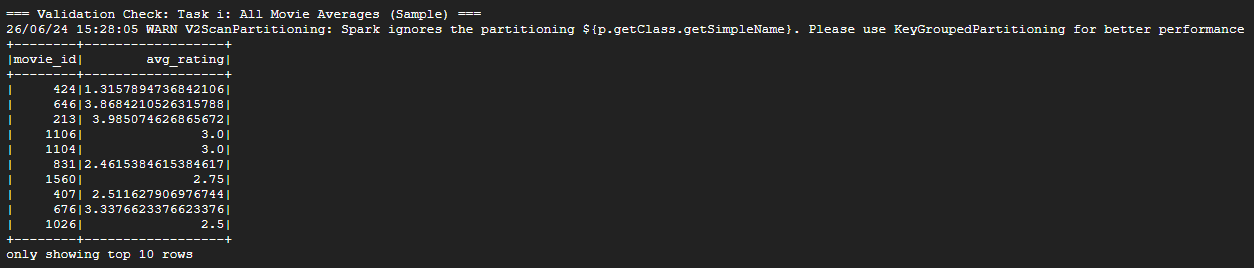

The resulting table shows the average rating received by each movie based on all user ratings available in the MovieLens 100K dataset. Only the first ten records are displayed for validation purposes. The average ratings in this sample range from approximately 2.46 to 3.99, indicating varying levels of user satisfaction across different movies. Calculating the average rating provides a straightforward measure of how positively each movie is perceived by users. Movies with higher average ratings generally indicate greater user satisfaction, while lower averages suggest less favourable opinions. However, average ratings alone do not accurately reflect the overall user preference. For instance, a movie rated by only a few users may obtain a high average score that is less representative than a movie with hundreds of ratings. Recommendation systems therefore often combine average ratings with rating frequency or weighted ranking approaches (Ricci et al., 2022). Nevertheless, this aggregation serves as the foundation for subsequent analyses, such as identifying the highest-rated movies in the dataset.

**Reference:**

Ricci, F., Rokach, L., & Shapira, B. (Eds.). (2022). Recommender Systems Handbook. Springer US. https://doi.org/10.1007/978-1-0716-2197-4

### 6.2 Top Ten Movies with the Highest Average Ratings
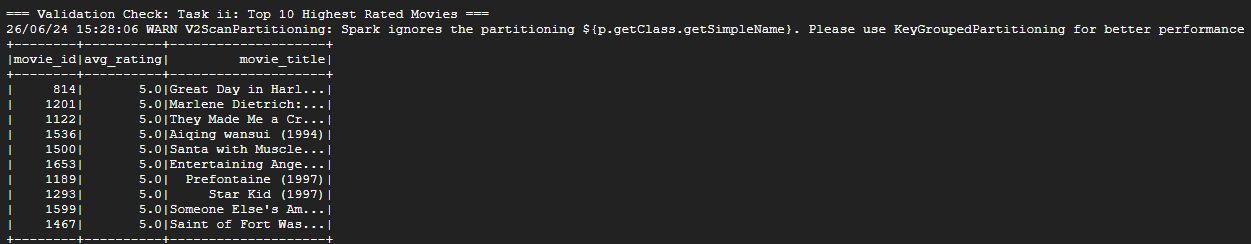

The output shows the top ten movies with the highest average ratings in the MovieLens 100K dataset. All movies displayed achieved an average rating of 5.0, suggesting that every recorded rating for these movies was the highest possible score. While average ratings may help to identify films that received the most positive feedback from users, they do not reflect the popularity or reliability of a movie. Several movies had achieved a rating of 5.0, but this does not necessarily mean that they are the best or most popular films in the dataset. Some of the movies may have received ratings from only a small number of users, making their averages less representative of the overall user population. In practice, recommendation systems often combine average ratings with the total number of ratings or apply weighted ranking methods to reduce the influence of movies with limited user feedback. Therefore, while the results successfully identify the highest-rated movies according to average score, additional metrics would improve the robustness of the ranking.

### 6.3 Users Rated At Least 50 Movies and Their Favourite Genre
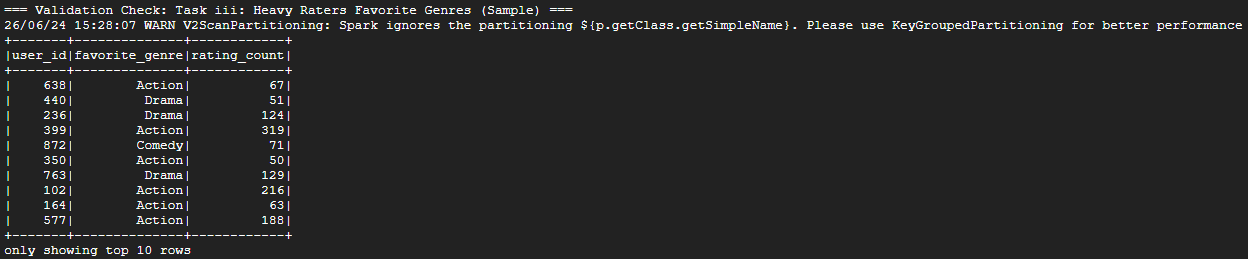
The results show users rated at least 50 movies along with their most frequently rated genre with the corresponding number of ratings. The sample indicates that Action and Drama are the most common favourite genres while Comedy also appears for a certain users. This suggests strong view preferences toward those genres. This information allows the identification of personal preferences which can be used to develop personalized recommendation systems. However, using the most frequently  rated genre as the sole indicator of user preference has certain limitations. A user may rate many movies from a particular genre simply because more titles are available in that genre rather than because it is their true favourite. Besides, the analysis considers only the frequency of ratings rather than the rating values themselves. A more comprehensive preference model could incorporate both the number of movies rated and the average rating assigned to each genre, providing a more accurate representation of user interests. 

### 6.4 Users Less Than 20 Years Old
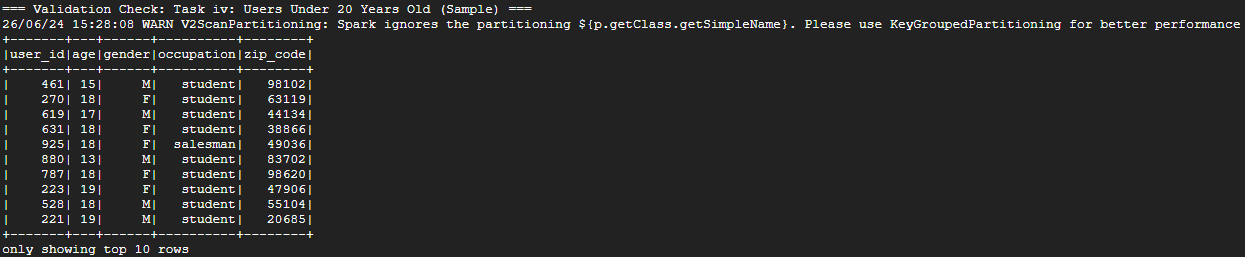
Filtering users based on demographic characteristics enables organizations to focus on specific user segments. The age-based segmentation can be applied in recommendation systems, marketing campaigns and customer behaviour analysis that personalizes recommendations based on different age groups. The output displays a sample of users below the age of 20. Most users in the sample are between 15 and 19 years old, with student being the dominant occupation. This suggests that educational status may influence movie consumption behaviour. Such information could help streaming platforms recommend age-appropriate content or design promotional campaigns targeted at younger audiences.

### 6.5 Uses Whose Occupation is 'Scientist" and Aged Between 30 and 40 Years Old
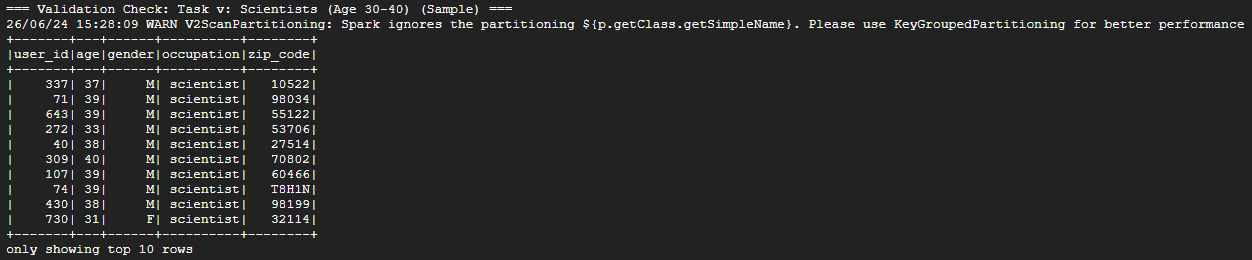
Combining demographic variables such as occupation and age allows more targeted user segmentation than filtering on a single attribute alone. Such queries are used to identify specific customer groups for detailed analysis. The output reveals a sample of users satisfying both filtering criteria. The displayed scientists are primarily between 31 and 40 years old, with both male and female users represented in the results. Each record includes demographic information such as user ID, gender, occupation, and ZIP code. This resulting subset could support further investigations into whether users with scientific professions exhibit different movie preferences, rating behaviours, or genre interests compared with users from other occupations. For example, future analyses could compare their average ratings, preferred genres, or rating frequencies against other professional groups.

## 7.0 Conclusion
This analysis implemented an end-to-end data analytics pipeline using Apache Spark and Apache Cassandra on the MovieLens 100K dataset. The analyses provided useful insights into movie ratings and user demographics. Although several movies achieved a perfect average rating of 5.0, these results should be interpreted alongside the number of ratings received, as movies with fewer ratings may obtain inflated average scores. Among users who rated at least 50 movies, Action and Drama emerged as the most frequently preferred genres, indicating strong engagement with these categories. The demographic analyses showed that users younger than 20 years old were predominantly students, while scientists aged between 30 and 40 represented a relatively small user group. These findings demonstrate how user ratings and demographic information can be combined to uncover viewing preferences and characterize different user segments. Such insights may provide a foundation for applications such as personalized recommendations, user segmentation, and further behavioural analysis.